In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
path = Path("../data/es_dollar_bars.csv")
if not path.exists():
    raise FileNotFoundError("es_dollar_bars.csv not found.")

bars = pd.read_csv(path, parse_dates=["timestamp"])
bars = bars.sort_values("timestamp").reset_index(drop=True)
close = bars.set_index("timestamp")["close"].sort_index()

print(close.index.min(), close.index.max(), len(close))

2013-09-01 17:19:56.232000 2013-09-03 13:49:06.359000 149


In [4]:
def get_daily_vol(close, span=100):
    idx = close.index.searchsorted(close.index - pd.Timedelta(days=1))
    idx = idx[idx > 0]

    prev_idx = pd.Series(
        close.index[idx - 1],
        index=close.index[close.shape[0] - idx.shape[0]:]
    )

    daily_ret = close.loc[prev_idx.index].values / close.loc[prev_idx.values].values - 1
    daily_ret = pd.Series(daily_ret, index=prev_idx.index)

    return daily_ret.ewm(span=span).std()

daily_vol = get_daily_vol(close)

In [5]:
def cusum_filter(close, threshold):
    log_ret = np.log(close).diff().dropna()
    s_pos, s_neg = 0.0, 0.0
    events = []

    for t in log_ret.index:
        if t not in threshold.index:
            continue

        h = threshold.loc[t]
        if pd.isna(h) or h <= 0:
            continue

        x = log_ret.loc[t]
        s_pos = max(0.0, s_pos + x)
        s_neg = min(0.0, s_neg + x)

        if s_neg < -h:
            s_neg = 0.0
            events.append(t)
        elif s_pos > h:
            s_pos = 0.0
            events.append(t)

    return pd.DatetimeIndex(events)

threshold = daily_vol.reindex(close.index, method="ffill")
t_events = cusum_filter(close, threshold)

print("CUSUM events:", len(t_events))

CUSUM events: 13


In [6]:
def add_vertical_barrier(t_events, close, num_hours=6):
    positions = close.index.searchsorted(
        t_events + pd.Timedelta(hours=num_hours)
    )

    valid = positions < len(close)
    positions = positions[valid]
    valid_events = t_events[valid]

    return pd.Series(close.index[positions], index=valid_events)

t1 = add_vertical_barrier(t_events, close, num_hours=6)

print("Valid vertical barriers:", len(t1))

Valid vertical barriers: 2


In [7]:
trgt = daily_vol.reindex(t_events, method="ffill").dropna()
common_events = trgt.index.intersection(t1.index)

trgt = trgt.loc[common_events]
t1 = t1.loc[common_events]

def apply_triple_barrier(close, t_events, t1, trgt, pt_sl=(1,1)):
    records = []

    for t0 in t_events:
        end = t1.loc[t0]
        target = trgt.loc[t0]
        path = close.loc[t0:end]

        if len(path) < 2:
            continue

        path_ret = path / path.iloc[0] - 1

        pt_touch = pd.NaT
        sl_touch = pd.NaT

        if pt_sl[0] > 0:
            hit = path_ret[path_ret > pt_sl[0] * target]
            if not hit.empty:
                pt_touch = hit.index[0]

        if pt_sl[1] > 0:
            hit = path_ret[path_ret < -pt_sl[1] * target]
            if not hit.empty:
                sl_touch = hit.index[0]

        candidates = [end]
        if pd.notna(pt_touch):
            candidates.append(pt_touch)
        if pd.notna(sl_touch):
            candidates.append(sl_touch)

        first_touch = min(candidates)

        if pd.notna(pt_touch) and first_touch == pt_touch:
            barrier = "pt"
        elif pd.notna(sl_touch) and first_touch == sl_touch:
            barrier = "sl"
        else:
            barrier = "vertical"

        records.append({
            "t0": t0,
            "t1": first_touch,
            "trgt": target,
            "first_barrier": barrier
        })

    return pd.DataFrame(records).set_index("t0")

events = apply_triple_barrier(close, common_events, t1, trgt, pt_sl=(1,1))
display(events.head())
display(events["first_barrier"].value_counts())

,t1,trgt,first_barrier
t0,,,
2013-09-03 00:12:57.042,2013-09-03 02:25:43.889,0.000383,sl
2013-09-03 03:54:27.751,2013-09-03 07:49:37.527,0.001599,pt


first_barrier
sl    1
pt    1
Name: count, dtype: int64

In [8]:
def get_bins(events, close):
    out = pd.DataFrame(index=events.index)

    out["ret"] = [
        close.loc[row["t1"]] / close.loc[t0] - 1
        for t0, row in events.iterrows()
    ]

    out["bin"] = np.sign(out["ret"]).astype(int)
    return out

labels = get_bins(events, close)
events_labeled = events.join(labels)

display(events_labeled["bin"].value_counts())

bin
-1    1
 1    1
Name: count, dtype: int64

In [9]:
def drop_labels(events, min_pct=0.05):
    out = events.copy()

    while True:
        freq = out["bin"].value_counts(normalize=True)

        if freq.empty:
            break

        rarest_label = freq.idxmin()
        rarest_pct = freq.min()

        if rarest_pct > min_pct or len(freq) < 3:
            break

        print(f"Dropping label {rarest_label}: {rarest_pct:.2%}")
        out = out[out["bin"] != rarest_label]

    return out

print("Before:")
display(events_labeled["bin"].value_counts(normalize=True).sort_index())

filtered_events = drop_labels(events_labeled, min_pct=0.05)

print("After:")
display(filtered_events["bin"].value_counts(normalize=True).sort_index())

Before:


bin
-1    0.5
 1    0.5
Name: proportion, dtype: float64

After:


bin
-1    0.5
 1    0.5
Name: proportion, dtype: float64

In [10]:
def get_bins_vertical_zero(events, close):
    out = pd.DataFrame(index=events.index)

    out["ret"] = [
        close.loc[row["t1"]] / close.loc[t0] - 1
        for t0, row in events.iterrows()
    ]

    out["bin"] = np.sign(out["ret"]).astype(int)

    vertical_mask = events["first_barrier"] == "vertical"
    out.loc[vertical_mask, "bin"] = 0

    return out

labels_vertical_zero = get_bins_vertical_zero(events, close)

comparison = pd.DataFrame({
    "Original": labels["bin"].value_counts().sort_index(),
    "Vertical=0": labels_vertical_zero["bin"].value_counts().sort_index()
}).fillna(0).astype(int)

display(comparison)

,Original,Vertical=0
bin,,
-1,1,1
1,1,1


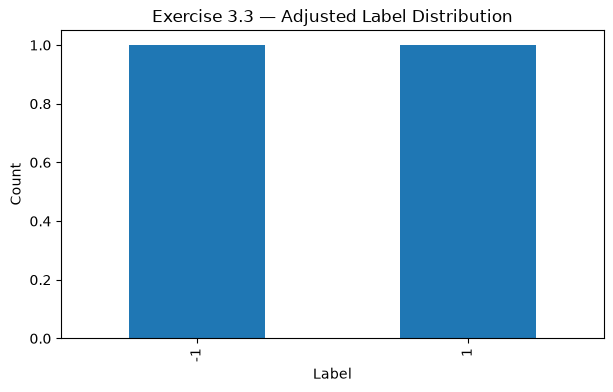

In [11]:
plt.figure(figsize=(7,4))
labels_vertical_zero["bin"].value_counts().sort_index().plot(kind="bar")
plt.title("Exercise 3.3 — Adjusted Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()